In [123]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [141]:
def load_test_result(folder_path):
    """
    Load test results from a specified folder.
    """
    file_path = os.path.join(folder_path, "test_metrics.csv")
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Test results file not found: {file_path}")
    
    df = pd.read_csv(file_path, sep=";", index_col=0)
    df = df.loc[["AUC"]]
    df = df.drop(columns=["MEAN"])
    return df

In [150]:
root_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\1. MultiTox_HNC\Feb_2025_results\TRP_all_pairs"

os.listdir(root_dir)

all_dfs = []

for folder in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder)
    if os.path.isdir(folder_path):
        df = load_test_result(folder_path)

        all_dfs.append(df.copy())


df_all = pd.concat(all_dfs, axis=0)



In [151]:
# Example dictionary to add as a new row
new_row = {
    'Aspiration_M06': 0.74,
    'Dysphagia_M06': 0.83,
    'Sticky_M06': 0.69,
    'Taste_M06': 0.67,
    'Xerostomia_M06': 0.80
}

# Append the new row to df_all
df_all = pd.concat([df_all, pd.DataFrame([new_row], index=['AUC'])], ignore_index=False)

In [ ]:
single_task_aucs = {"Aspiration_M06" : 0.71,
                    "Dysphagia_M06" : 0.82,
                    "Sticky_M06" : 0.71,
                    "Taste_M06" : 0.71,
                    "Xerostomia_M06" : 0.78}

# single_task_ACEs = {"Aspiration_M06" : 0.055,
#                     "Dysphagia_M06" : 0.072,
#                     "Sticky_M06" : 0.115,
#                     "Taste_M06" : 0.088,
#                     "Xerostomia_M06" : 0.108}


# Add each single_task_ACE as its own row, filling other columns with None
for endpoint, ace in single_task_aucs.items():
    row = {col: None for col in df_all.columns}
    row[endpoint] = ace
    df_all = pd.concat([df_all, pd.DataFrame([row], index=['ACE'])], ignore_index=False)


C:\Users\macraedc\AppData\Local\Temp\ipykernel_36928\1956534974.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([df_all, pd.DataFrame([row], index=['ACE'])], ignore_index=False)
C:\Users\macraedc\AppData\Local\Temp\ipykernel_36928\1956534974.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([df_all, pd.DataFrame([row], index=['ACE'])], ignore_index=False)
C:\Users\macraedc\AppData\Local\Temp\ipykernel_36928\1956534974.py:18: FutureWarning: The behavi

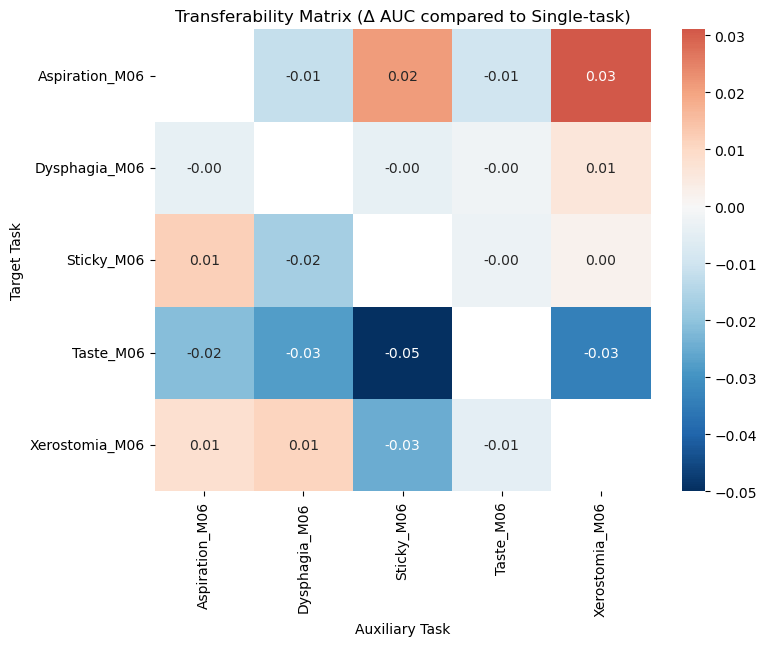

In [156]:
# Step 2: Calculate transferability


df_pairs_only = df_all[df_all.notna().sum(axis=1) == 2]

endpoints = df_all.columns.tolist()

transfer_matrix = pd.DataFrame(index=endpoints, columns=endpoints, dtype=float)

for _, row in df_pairs_only.iterrows():
    trained_tasks = row.dropna().index.tolist()
    if len(trained_tasks) != 2:
        continue  # We only want to compare task pairs

    t1, t2 = trained_tasks

    # Compute deltas
    if t1 in single_task_aucs and t2 in single_task_aucs:
        delta1 = row[t1] - single_task_aucs[t1]
        delta2 = row[t2] - single_task_aucs[t2]

        #print(delta1, delta2)

        transfer_matrix.loc[t1, t2] = delta1
        transfer_matrix.loc[t2, t1] = delta2
    else:
        print(f"Warning: {t1} or {t2} not found in single-task AUCs.")

# Step 3: Plot transferability heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(transfer_matrix, annot=True, center=0, cmap='RdBu_r', linewidths=0, fmt=".2f")
plt.title("Transferability Matrix (Δ AUC compared to Single-task)")
plt.xlabel("Auxiliary Task")
plt.ylabel("Target Task")
plt.show()

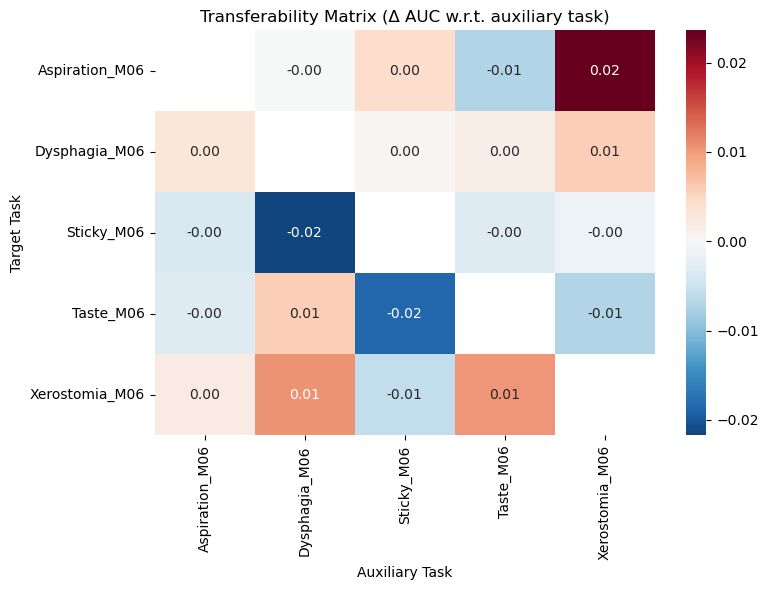

Top 10 positive transfers:
Aspiration_M06 <- Xerostomia_M06 : ΔAUC = 0.024
Xerostomia_M06 <- Dysphagia_M06 : ΔAUC = 0.011
Xerostomia_M06 <- Taste_M06 : ΔAUC = 0.010
Taste_M06 <- Dysphagia_M06 : ΔAUC = 0.006
Dysphagia_M06 <- Xerostomia_M06 : ΔAUC = 0.006
Aspiration_M06 <- Sticky_M06 : ΔAUC = 0.004
Dysphagia_M06 <- Aspiration_M06 : ΔAUC = 0.003
Xerostomia_M06 <- Aspiration_M06 : ΔAUC = 0.002
Dysphagia_M06 <- Taste_M06 : ΔAUC = 0.002
Dysphagia_M06 <- Sticky_M06 : ΔAUC = 0.000

Top 10 negative transfers:
Sticky_M06 <- Dysphagia_M06 : ΔAUC = -0.022
Taste_M06 <- Sticky_M06 : ΔAUC = -0.019
Aspiration_M06 <- Taste_M06 : ΔAUC = -0.007
Taste_M06 <- Xerostomia_M06 : ΔAUC = -0.007
Xerostomia_M06 <- Sticky_M06 : ΔAUC = -0.006
Sticky_M06 <- Aspiration_M06 : ΔAUC = -0.004
Taste_M06 <- Aspiration_M06 : ΔAUC = -0.003
Sticky_M06 <- Taste_M06 : ΔAUC = -0.003
Sticky_M06 <- Xerostomia_M06 : ΔAUC = -0.001
Aspiration_M06 <- Dysphagia_M06 : ΔAUC = -0.000


In [155]:
import pandas as pd
import numpy as np
import itertools
import seaborn as sns
import matplotlib.pyplot as plt

# df: assumed to have one row per model (endpoint combo) and columns = ['Aspiration', 'Dysphagia', ..., etc.]
# Each cell has an AUC or None

df = df_all.copy()

# Get all endpoint/task names
tasks = list(df.columns)

# Create transferability matrix
transfer_matrix = pd.DataFrame(index=tasks, columns=tasks, dtype=float)

# Iterate over task pairs
for task_a, task_b in itertools.permutations(tasks, 2):
    # Get AUCs where only task_a is trained
    # task_b is the auxiliary task
    # task_a is the target task
    auc_single = single_task_aucs[task_a]
    auc_pair = df[df[task_a].notna() & df[task_b].notna()][task_a]

    auc_disjoint_pair = df[df[task_a].notna() & df[task_b].isna()][task_a]

    if not auc_pair.empty:
        #mean_single = auc_single
        mean_without = auc_disjoint_pair.mean() 
        mean_pair = auc_pair.mean()
        transfer_matrix.loc[task_a, task_b] = mean_pair - mean_without

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(transfer_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title("Transferability Matrix (Δ AUC w.r.t. auxiliary task)")
plt.xlabel("Auxiliary Task")
plt.ylabel("Target Task")
plt.tight_layout()
plt.show()

# Optional: print top positive transfer pairs
transfer_scores = []
for task_a, task_b in itertools.permutations(tasks, 2):
    score = transfer_matrix.loc[task_a, task_b]
    if pd.notnull(score):
        transfer_scores.append((task_a, task_b, score))

# Sort and display top 10
top_transfers = sorted(transfer_scores, key=lambda x: -x[2])
print("Top 10 positive transfers:")
for a, b, s in top_transfers[:10]:
    print(f"{a} <- {b} : ΔAUC = {s:.3f}")

# Sort and display top 10 negative transfers
bottom_transfers = sorted(transfer_scores, key=lambda x: x[2])
print("\nTop 10 negative transfers:")
for a, b, s in bottom_transfers[:10]:
    print(f"{a} <- {b} : ΔAUC = {s:.3f}")


In [130]:
df[df[task_a].notna() & df[task_b].isna()]

,Aspiration_M06,Dysphagia_M06,Sticky_M06,Taste_M06,Xerostomia_M06
AUC,0.727,0.820,0.698,NaN,0.772
AUC,0.733,0.824,NaN,NaN,0.771
AUC,0.744,NaN,0.698,NaN,0.758
AUC,0.741,NaN,NaN,NaN,0.788
AUC,NaN,0.827,0.684,NaN,0.777
AUC,NaN,0.826,NaN,NaN,0.791
AUC,NaN,NaN,0.712,NaN,0.755
